<a href="https://colab.research.google.com/github/dinujakr/Final-year-project-IEKF-for-rigid-body-tracking/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Simulation and experimental verification of a Intrinsic Extended Kalman filter for rigid body attitude tracking

#Linear Kalman Filter

Testing the linear kalman filter under smooth and rapid rotations using EuroC Datasets

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Load Data sets

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# CHANGE THIS to switch between EuRoC MAV sequences
# Easy:   r"F:\Uni\FYP\ES7 3 exam\MH_01_easy"
# Medium: r"F:\Uni\FYP\ES7 3 example\MH_03_medium"
# Hard:   r"F:\Uni\FYP\ES7 3 example\MH_05_difficult"
# Very hard: r"F:\Uni\FYP\ES7 3 example\V2_03_difficult"

DATASET = "/content/drive/MyDrive/FYP/V2_03_difficult"
# ============================================================

imu_path = DATASET + r"/imu0/data.csv"
gt_path  = DATASET + r"/state_groundtruth_estimate0/data.csv"

# Load CSV
imu = pd.read_csv(imu_path)
gt  = pd.read_csv(gt_path)

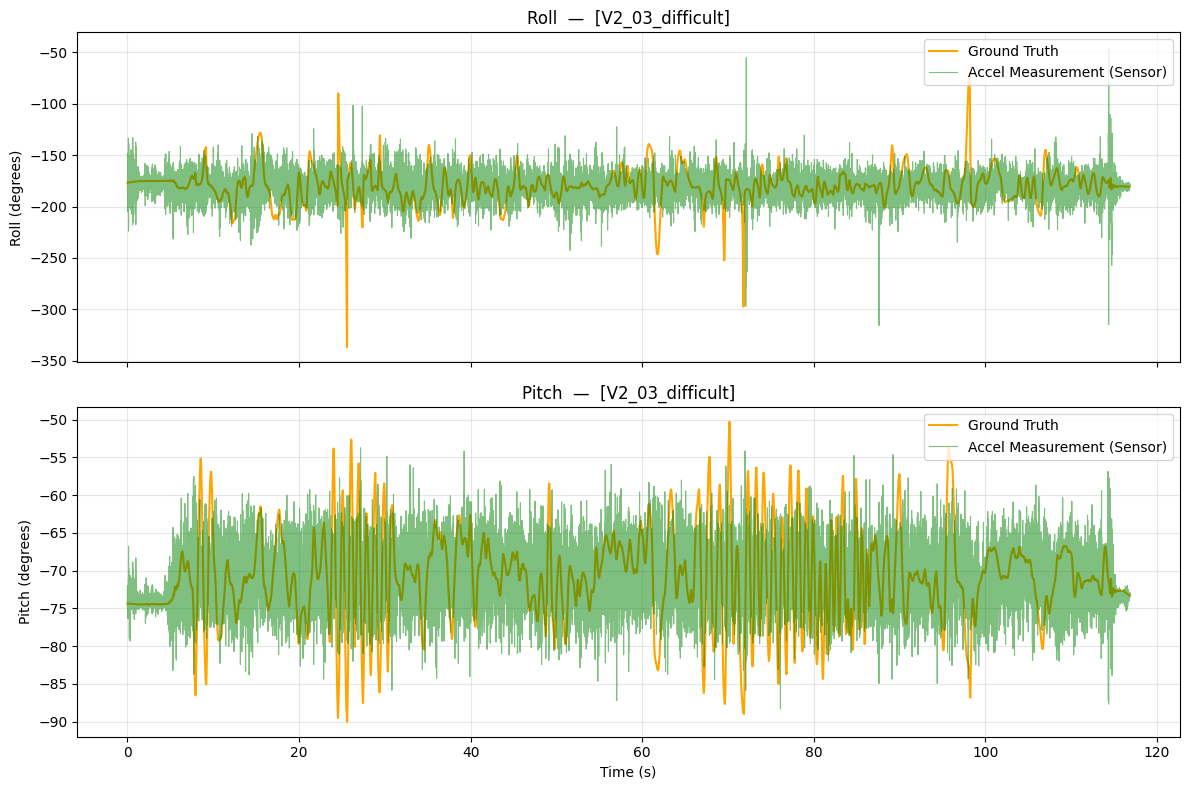

In [3]:
t0 = min(imu.iloc[0,0], gt.iloc[0,0])   # same global reference

# IMU Timeline and raw values
t_imu = (imu.iloc[:,0].values - t0) * 1e-9
gyro = imu.iloc[:,1:4].values   # wx, wy, wz
acc  = imu.iloc[:,4:7].values   # ax, ay, az

# GT Timeline
t_gt  = (gt.iloc[:,0].values  - t0) * 1e-9

# Quaternion
q_gt = gt[[' q_RS_w []',' q_RS_x []',' q_RS_y []',' q_RS_z []']].values


# --- CONVERSION & UTILITY FUNCTIONS ---

# Convert accelerometer to Euler angles
def accel_to_euler(acc):
    ax, ay, az = acc
    norm = np.linalg.norm(acc)
    if norm == 0:
        return np.array([0.0, 0.0])
    ax, ay, az = ax/norm, ay/norm, az/norm

    phi = np.arctan2(ay, az)
    theta = np.arctan2(-ax, np.sqrt(ay**2 + az**2))

    return np.array([phi, theta])

# Convert Ground Truth Quaternions to Euler angles
def quat_to_euler(q):
    w, x, y, z = q
    phi = np.arctan2(2 * (w*x + y*z), 1 - 2 * (x*x + y*y))
    sin_pitch = np.clip(2 * (w*y - z*x), -1.0, 1.0)
    theta = np.arcsin(sin_pitch)
    psi = np.arctan2(2 * (w*z + x*y), 1 - 2 * (y*y + z*z))
    return np.array([phi, theta, psi])

# Properly unwrap cumulative angle trajectories to remove ±π wrap jumps
def unwrap_angle(a):
    a_unwrapped = np.copy(a)
    for i in range(1, len(a_unwrapped)):
        diff = a_unwrapped[i] - a_unwrapped[i-1]
        while diff > np.pi:
            a_unwrapped[i] -= 2 * np.pi
            diff -= 2 * np.pi
        while diff < -np.pi:
            a_unwrapped[i] += 2 * np.pi
            diff += 2 * np.pi
    return a_unwrapped


# --- DATA PROCESSING ---

# 1. Compute and unwrap direct sensor orientations from entire Accelerometer log
roll_meas = np.arctan2(acc[:, 1], acc[:, 2])
pitch_meas = np.arctan2(-acc[:, 0], np.sqrt(acc[:, 1]**2 + acc[:, 2]**2))

roll_meas = unwrap_angle(roll_meas)
pitch_meas = unwrap_angle(pitch_meas)

# 2. Extract full Ground Truth Euler angles from quaternions and unwrap them
euler_gt = np.array([quat_to_euler(q) for q in q_gt])
euler_gt[:, 0] = unwrap_angle(euler_gt[:, 0])
euler_gt[:, 1] = unwrap_angle(euler_gt[:, 1])

# 3. Interpolate Ground Truth data perfectly over the IMU sensor timeline
interp_gt_roll  = interp1d(t_gt, euler_gt[:, 0], bounds_error=False, fill_value='extrapolate')
interp_gt_pitch = interp1d(t_gt, euler_gt[:, 1], bounds_error=False, fill_value='extrapolate')

gt_roll_unwrapped  = interp_gt_roll(t_imu)
gt_pitch_unwrapped = interp_gt_pitch(t_imu)

dataset_name = DATASET.split("/")[-1]


# --- PLOTTING DATA ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Roll subplot ---
ax1.plot(t_imu, np.degrees(gt_roll_unwrapped), label='Ground Truth', color='orange', linewidth=1.5)
ax1.plot(t_imu, np.degrees(roll_meas), label='Accel Measurement (Sensor)', color='green', alpha=0.5, linewidth=0.8)
ax1.set_ylabel("Roll (degrees)")
ax1.set_title(f"Roll  —  [{dataset_name}]")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Pitch subplot ---
ax2.plot(t_imu, np.degrees(gt_pitch_unwrapped), label='Ground Truth', color='orange', linewidth=1.5)
ax2.plot(t_imu, np.degrees(pitch_meas), label='Accel Measurement (Sensor)', color='green', alpha=0.5, linewidth=0.8)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Pitch (degrees)")
ax2.set_title(f"Pitch  —  [{dataset_name}]")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()